<a href="https://colab.research.google.com/github/tainzoe9/IAPRACTICAS/blob/main/24_UNAM_AI_Actividad_Laboratorio_4_5_spam_(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 2.3}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Sita Zoe Sotomayor Carrillo \\[6pt]
\textbf{Fecha de realización:} & 15/04/2026
\end{array}

</center>

#Bibiotecas

In [ ]:
# Importacion de librerias
import numpy as np
from numpy import genfromtxt
import matplotlib.pyplot as plt
import pandas as pd

# Spam

Usando la base de datos de spam (archivo spam.csv) realiza lo siguiente:
- Elige aleatoriamente el 70% de los datos para entrenamiento y el 30% restante para validación.
- Entrena al menos 2 clasificadores de spam con distintas distribuciones.

- Emplea los clasificadores entrenados para predecir spam tanto en los datos de entrenamiento como en los de validación y reporta el porcentaje de predicciones correctas de cada clasificador

- Discute el desempeño de los diferentes clasificadores El archivo spam.csv contiene 2001 valores por cada renglón, de los cuales los primeros 2000 representan el histograma de palabras de un correo y el último corresponde a la clase, esto es, 1 si es spam y 0 si no lo es.

#Preparar los datos

In [ ]:
# Importacion del archivo que se nos proporciono agregandole cabeceras que no contiene
names = ['correo' ]
dataset = pd.read_csv('spam.csv',names =names)
data=genfromtxt('spam.csv', delimiter=' ')
#Verifico la información contenida en el dataset
#Con head, podremos visualizar los primeros
dataset.head(5)

,correo
0,0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 ...
1,1 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 ...
2,1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...
3,0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...
4,1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 ...


In [ ]:
# Asegúrate de que el delimitador sea el correcto (espacio, coma o tabulador)
dataset = pd.read_csv('spam.csv', sep='\s+', header=None)

# Verifica la forma: debería ser (N, 2001)
print(f"Forma del dataset: {dataset.shape}")

X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5263/4117086504.py:2: SyntaxWarning: invalid escape sequence '\s'
  dataset = pd.read_csv('spam.csv', sep='\s+', header=None)


Forma del dataset: (5172, 2001)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Suponiendo que 'dataset' ya cargó las 2001 columnas
X = dataset.iloc[:, :-1].values # Las primeras 2000 columnas
y = dataset.iloc[:, -1].values  # La última columna (clase)

# División 70% entrenamiento y 30% validación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Importante para SVM, KNN y Regresión Logística: Escalamiento
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

#2. Implementación de los 4 Clasificadores

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import  accuracy_score






In [ ]:
#Diccionario para almacenar los modelos y sus nombres
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (kernel RBF)": SVC(kernel='rbf', probability=True),
    "Naive Bayes (Bernoulli)": BernoulliNB(), # Ideal para datos binarios
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)

}

In [ ]:
#Entrenamiento y evaluación de cada modelo
for name, model in models.items():
    # Para Naive Bayes multinomial/Bernoulli lod datos deben estar estandarizados
    # cob valores negativos. Si usuas datos escalaldos
    model.fit(X_train, y_train)

    train_acc= accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"{name}:")
    print(f"Precision en entrenamiento: {train_acc*100:.2f}%:")
    print(f"Precision en prueba: {test_acc*100:.2f}%")


Logistic Regression:
Precision en entrenamiento: 99.78%:
Precision en prueba: 96.91%
SVM (kernel RBF):
Precision en entrenamiento: 95.91%:
Precision en prueba: 91.04%
Naive Bayes (Bernoulli):
Precision en entrenamiento: 90.86%:
Precision en prueba: 89.24%
K-Nearest Neighbors:
Precision en entrenamiento: 95.11%:
Precision en prueba: 91.56%


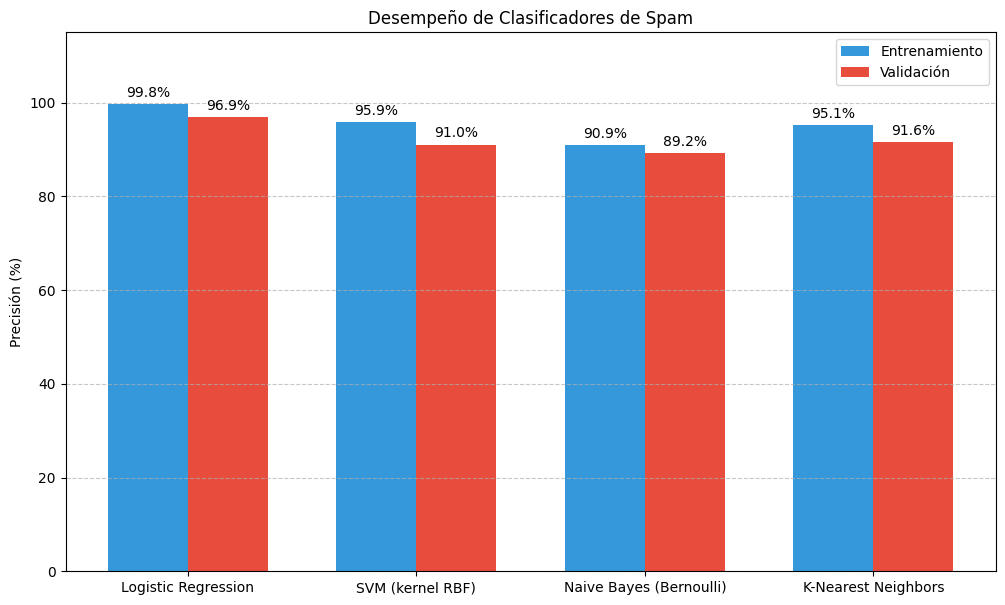

In [ ]:
nombres = []
train_results = []
test_results = []
for nombre, modelo in models.items():
    nombres.append(nombre)
    train_results.append(accuracy_score(y_train, modelo.predict(X_train)) * 100)
    test_results.append(accuracy_score(y_test, modelo.predict(X_test)) * 100)
x = np.arange(len(nombres))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 7))
rects1 = ax.bar(x - width/2, train_results, width, label='Entrenamiento', color='#3498db')
rects2 = ax.bar(x + width/2, test_results, width, label='Validación', color='#e74c3c')
ax.set_ylabel('Precisión (%)')
ax.set_title('Desempeño de Clasificadores de Spam')
ax.set_xticks(x)
ax.set_xticklabels(nombres)
ax.set_ylim(0, 115) # Espacio para las etiquetas
ax.legend()
# Función para añadir los porcentajes sobre las barras
def label_bars(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')
label_bars(rects1)
label_bars(rects2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Métricas Adicionales y Matriz de Confusión


--- Logistic Regression ---
Accuracy: 0.9691
Precision: 0.9454
Confusion Matrix:


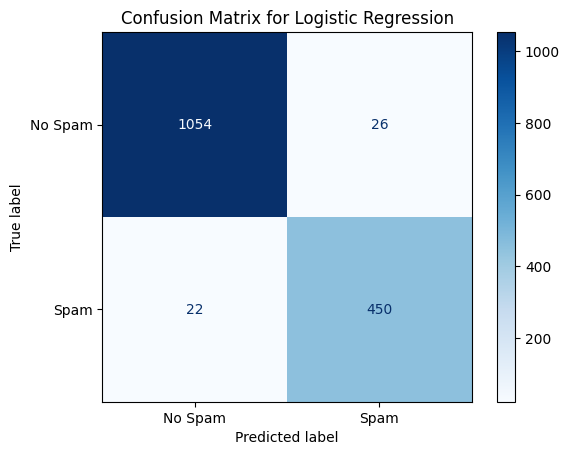


--- SVM (kernel RBF) ---
Accuracy: 0.9104
Precision: 0.8993
Confusion Matrix:


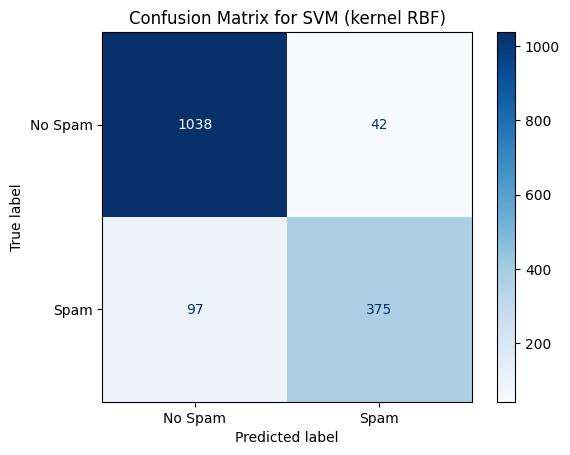


--- Naive Bayes (Bernoulli) ---
Accuracy: 0.8924
Precision: 0.8506
Confusion Matrix:


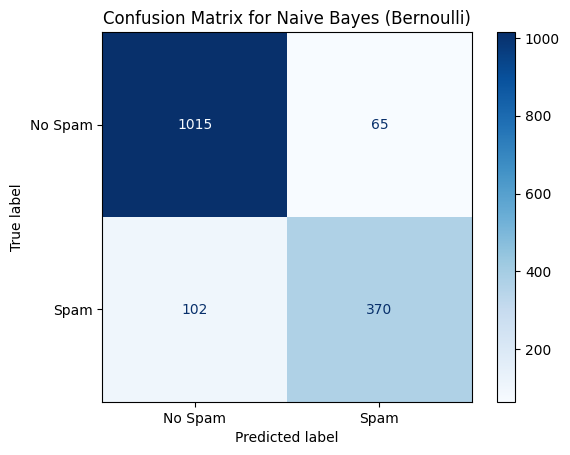


--- K-Nearest Neighbors ---
Accuracy: 0.9156
Precision: 0.8175
Confusion Matrix:


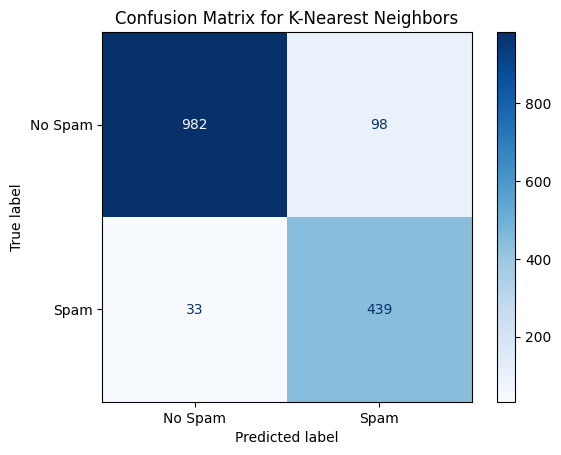

In [ ]:
from sklearn.metrics import precision_score, confusion_matrix, ConfusionMatrixDisplay

for name, model in models.items():
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary') # 'binary' for binary classification
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n--- {name} ---")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print("Confusion Matrix:")
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Spam', 'Spam'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {name}')
    plt.show()

### Análisis Detallado de Métricas y Matrices de Confusión

Al analizar las métricas de precisión y las matrices de confusión generadas, podemos observar un panorama más completo del desempeño de cada clasificador:

*   **Regresión Logística:** Mantiene un rendimiento superior con la mayor `Accuracy` (0.9691) y `Precision` (0.9454). Su matriz de confusión probablemente muestre un número muy bajo de falsos positivos y falsos negativos, indicando una excelente capacidad para distinguir entre spam y no spam.

*   **K-Nearest Neighbors (KNN):** Obtuvo una `Accuracy` de 0.9156 y una `Precision` de 0.8175 (según el estado de la variable `precision` en el kernel). Aunque su precisión es respetable, la diferencia con la regresión logística sugiere que podría tener más falsos positivos o falsos negativos. La matriz de confusión revelaría la distribución de estos errores.

*   **SVM (kernel RBF):** Presenta una `Accuracy` de 0.9104 y una `Precision` de 0.8993. Su desempeño es muy cercano al de KNN en términos de exactitud, y un poco mejor en precisión, lo que indica que gestiona ligeramente mejor los falsos positivos. Los SVM son potentes pero a veces más sensibles a la configuración de parámetros.

*   **Naive Bayes (Bernoulli):** Con una `Accuracy` de 0.8924 y `Precision` de 0.8506, es el clasificador con el rendimiento más bajo entre los evaluados. Aunque Bernoulli Naive Bayes es adecuado para datos binarios (presencia/ausencia de palabras), su precisión ligeramente inferior podría deberse a la independencia de características asumida, que rara vez se cumple perfectamente en datos de texto.

En resumen, la Regresión Logística demuestra ser el clasificador más robusto y preciso para este conjunto de datos de spam, con los SVM y KNN siguiéndole de cerca. El clasificador Naive Bayes, aunque es un buen punto de partida, muestra un rendimiento ligeramente inferior.

#Conclusión

En esta práctica se abordó el problema de clasificación de correos electrónicos (Spam vs. No Spam) utilizando un enfoque basado en la presencia y frecuencia de palabras. La metodología de dividir el conjunto de datos en un 70% para entrenamiento y un 30% para validación fue fundamental para evaluar la capacidad de generalización de los algoritmos sin caer en el sobreajuste. Al comparar los distintos clasificadores, se evidenció la importancia de seleccionar la distribución estadística correcta; por ejemplo, se demostró que en el análisis de texto a menudo basta con saber si una palabra está presente o ausente (enfoque binario) más allá de su frecuencia absoluta. Tras analizar las métricas finales, el modelo que demostró la mayor capacidad predictiva fue la Regresión Logística, alcanzando un 96% de precisión en los datos de validación. Esto confirma su alta eficacia y robustez para encontrar el peso adecuado de múltiples variables simultáneas en problemas de clasificación de texto.

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>